## COMSOL Lead Field → 전기장 크기 계산

**컬럼 구조**: `x, y, Ex@idx=1(복소수), Ey@idx=1, Ex@idx=2, Ey@idx=2`  
**원리**: Anti-phase 채널 전기장 = `E_idx1 - E_idx2` (실수부 사용) → `|E| = sqrt(Ex² + Ey²)`

참고 코드: `KDY_optimization_electrode_origin.ipynb` — `load_leadfield_data`, `compute_AM_Grossman`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
from scipy.spatial import cKDTree


# 한글 폰트 설정 (Windows: Malgun Gothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

In [2]:
SIM_DIR = Path(r"D:\00_Project\nTIS\docs\07_Simulation")

# f1 lead field 파일 (채널 1: 전극 1,2)
LEADFIELD_F1 = SIM_DIR / "20260626_TI_field_Base_X50_Y50_point_leadField_f1_ver2.csv"
# f2 lead field 파일 (채널 2: 전극 3,4)
LEADFIELD_F2 = SIM_DIR / "20260626_TI_field_Base_X50_Y50_point_leadField_f2_ver2.csv"

# 검증용 파일 경로 (COMSOL 시뮬레이션 결과)
VAL_FILE = SIM_DIR / "20260626_TI_field_Base_X50_Y50_point_ver2.csv"
AM_VECTOR_FILE = SIM_DIR / "20260626_TI_field_Base_X50_Y50_point_AM_vector.csv"

CURRENT_F1_MA = 1.0   # 채널 1 (전극 1,2) 인가 전류 [mA]
CURRENT_F2_MA = 1.0   # 채널 2 (전극 3,4) 인가 전류 [mA]

print(f"f1 lead field: {LEADFIELD_F1.name}  존재: {LEADFIELD_F1.exists()}")
print(f"f2 lead field: {LEADFIELD_F2.name}  존재: {LEADFIELD_F2.exists()}")
print(f"검증 file: {VAL_FILE.name}  존재: {VAL_FILE.exists()}")
print(f"전류 — Ch1: {CURRENT_F1_MA} mA  /  Ch2: {CURRENT_F2_MA} mA")

f1 lead field: 20260626_TI_field_Base_X50_Y50_point_leadField_f1_ver2.csv  존재: True
f2 lead field: 20260626_TI_field_Base_X50_Y50_point_leadField_f2_ver2.csv  존재: True
검증 file: 20260626_TI_field_Base_X50_Y50_point_ver2.csv  존재: True
전류 — Ch1: 1.0 mA  /  Ch2: 1.0 mA


### 1. 데이터 로드

KDY `load_leadfield_data` 기반 — 2D(Ex, Ey)용으로 수정.

반환 형태:
- `coords`: `(N, 2)` — x, y 좌표 [mm]
- `E_tensor`: `(num_electrodes, N, 2)` — 각 전극의 [Ex, Ey] [V/m, 실수부]

In [3]:
def load_leadfield_2d(filepath, x_range=None, y_range=None):
    """
    COMSOL 2D lead field CSV 로드.
    - x_range/y_range=None 이면 데이터에서 도메인 자동 판단
    - NaN 행 제거
    - 준정적 전기장이므로 실수부만 사용 (허수부 ~1.5% 무시)
    반환: coords (N, 2), E_tensor (num_electrodes, N, 2)
    """
    print(f"Loading: {Path(filepath).name}")
    df = pd.read_csv(filepath, comment='%', header=None)

    # NaN 행 제거
    n_before = len(df)
    df = df.dropna().reset_index(drop=True)
    if len(df) < n_before:
        print(f"  [!] NaN 행 제거: {n_before - len(df)}개")

    cx = df.iloc[:, 0].values.astype(float)
    cy = df.iloc[:, 1].values.astype(float)

    # 도메인 자동 판단 (None이면 데이터 범위 그대로 사용)
    if x_range is None:
        x_range = (float(cx.min()), float(cx.max()))
    if y_range is None:
        y_range = (float(cy.min()), float(cy.max()))
    print(f"  도메인 — x: [{x_range[0]:.2f}, {x_range[1]:.2f}] mm  "
          f"y: [{y_range[0]:.2f}, {y_range[1]:.2f}] mm")

    # 좌표 범위 필터링
    mask = (
        (cx >= x_range[0]) & (cx <= x_range[1]) &
        (cy >= y_range[0]) & (cy <= y_range[1])
    )
    if (~mask).sum():
        print(f"  [!] 범위 밖 노드 제거: {(~mask).sum()}개")
    df = df[mask].reset_index(drop=True)

    coords     = df.iloc[:, :2].values.astype(float)
    field_cols = df.iloc[:, 2:]
    num_electrodes = field_cols.shape[1] // 2
    num_points     = len(df)

    # 복소수 파싱: 'i' → 'j', 실수부 추출
    parsed = np.zeros((num_points, field_cols.shape[1]), dtype=np.float64)
    for i in range(field_cols.shape[1]):
        col_str = (field_cols.iloc[:, i]
                   .fillna('0').astype(str)
                   .str.replace(' ', '', regex=False)
                   .str.replace('i', 'j', regex=False))
        parsed[:, i] = np.real(np.array([complex(v) for v in col_str]))

    E_tensor = np.zeros((num_electrodes, num_points, 2))
    for e in range(num_electrodes):
        E_tensor[e, :, 0] = parsed[:, e * 2]
        E_tensor[e, :, 1] = parsed[:, e * 2 + 1]

    print(f"  → 전극 {num_electrodes}개 / 유효 포인트 {num_points}개 / E_tensor: {E_tensor.shape}")
    return coords, E_tensor


coords, E_f1 = load_leadfield_2d(LEADFIELD_F1)
_,      E_f2 = load_leadfield_2d(LEADFIELD_F2)

x, y = coords[:, 0], coords[:, 1]
print(f"\n좌표 범위 — x: [{x.min():.2f}, {x.max():.2f}] mm  "
      f"y: [{y.min():.2f}, {y.max():.2f}] mm")

Loading: 20260626_TI_field_Base_X50_Y50_point_leadField_f1_ver2.csv
  도메인 — x: [-25.00, 25.00] mm  y: [-25.00, 25.00] mm
  → 전극 2개 / 유효 포인트 713개 / E_tensor: (2, 713, 2)
Loading: 20260626_TI_field_Base_X50_Y50_point_leadField_f2_ver2.csv
  도메인 — x: [-25.00, 25.00] mm  y: [-25.00, 25.00] mm
  → 전극 2개 / 유효 포인트 713개 / E_tensor: (2, 713, 2)

좌표 범위 — x: [-25.00, 25.00] mm  y: [-25.00, 25.00] mm


### 2. Anti-phase 채널 전기장 합성 & 크기 계산

각 파일의 두 전극(idx=1, idx=2)이 서로 **anti-phase** 쌍이므로 차분으로 채널 전기장 합성. (KDY 코드 루프 내 `Ef = E[a] - E[b]` 와 동일한 원리.)

$$\mathbf{E}_{ch} = \mathbf{E}_{idx=1} - \mathbf{E}_{idx=2}$$

$$|\mathbf{E}| = \sqrt{E_x^2 + E_y^2}$$

> **Note:** COMSOL Terminal이 이미 `1[mA]`로 계산 → CSV 값이 V/m @ 1mA.  별도 전류 스케일링 불필요.

In [4]:
# ── Anti-phase 채널 전기장 합성 ───────────────────────────────────────────────
# COMSOL Terminal = 1[mA]로 계산 → CSV already in V/m @ 1mA → 별도 스케일 불필요
Ef1 = E_f1[0] - E_f1[1]   # (N, 2): [Ex_f1, Ey_f1] [V/m]
Ef2 = E_f2[0] - E_f2[1]   # (N, 2): [Ex_f2, Ey_f2] [V/m]

print(f"Ef1 shape: {Ef1.shape}  (채널 1: 전극 1,2 / {CURRENT_F1_MA} mA)")
print(f"Ef2 shape: {Ef2.shape}  (채널 2: 전극 3,4 / {CURRENT_F2_MA} mA)")

# ── 전기장 크기 계산 ──────────────────────────────────────────────────────────
E_mag_f1 = np.linalg.norm(Ef1, axis=1)   # (N,) [V/m]
E_mag_f2 = np.linalg.norm(Ef2, axis=1)   # (N,) [V/m]

print("\n── |E_f1| 통계 (V/m) ──")
print(f"  max={E_mag_f1.max():.6f}  mean={E_mag_f1.mean():.6f}  median={np.median(E_mag_f1):.6f}")
print("── |E_f2| 통계 (V/m) ──")
print(f"  max={E_mag_f2.max():.6f}  mean={E_mag_f2.mean():.6f}  median={np.median(E_mag_f2):.6f}")

Ef1 shape: (713, 2)  (채널 1: 전극 1,2 / 1.0 mA)
Ef2 shape: (713, 2)  (채널 2: 전극 3,4 / 1.0 mA)

── |E_f1| 통계 (V/m) ──
  max=0.144902  mean=0.026624  median=0.010489
── |E_f2| 통계 (V/m) ──
  max=0.144931  mean=0.025897  median=0.010275


### 4. AM Modulation 계산 (Grossman 2017)

두 채널 전기장이 조직 내에서 간섭할 때 생기는 저주파 envelope.

$$AM_{max} = \max_{\hat{n}} \left[ 2 \cdot \min\left(|\mathbf{E}_{f1} \cdot \hat{n}|,\ |\mathbf{E}_{f2} \cdot \hat{n}|\right) \right]$$

`compute_AM_Grossman` — KDY `KDY_optimization_electrode_origin.ipynb` 에서 가져옴 (2D 그대로 적용 가능).

In [5]:
def compute_AM_Grossman(Ef1, Ef2):
    """
    Grossman 2017 AM modulation 계산.
    Ef1, Ef2: shape (N, 2) or (N, 3) — 각 채널의 전기장 벡터
    반환: AM_vector (N,) — 각 포인트의 AM envelope 크기 [V/m]
    """
    eps = 1e-15

    n1 = np.linalg.norm(Ef1, axis=1)
    n2 = np.linalg.norm(Ef2, axis=1)
    n1 = np.where(n1 == 0, eps, n1)
    n2 = np.where(n2 == 0, eps, n2)

    # 크기 기준으로 E_max / E_min 분류
    cond   = n1 > n2
    E_max  = np.where(cond[:, None], Ef1, Ef2)
    E_min  = np.where(cond[:, None], Ef2, Ef1)
    E1_amp = np.where(cond, n1, n2)
    E2_amp = np.where(cond, n2, n1)

    # 두 벡터 사이 각도
    dot_prod = np.sum(E_max * E_min, axis=1)
    cosB     = np.clip(dot_prod / (E1_amp * E2_amp), -1.0, 1.0)
    ang      = np.arccos(cosB)

    # 예각/둔각 분기
    acute_cond  = ang < (np.pi / 2)
    E_min_adj   = np.where(acute_cond[:, None], E_min, -E_min)
    cosA        = np.where(acute_cond, cosB, -cosB)

    E_m      = E_max - E_min_adj
    norm_E_m = np.linalg.norm(E_m, axis=1)
    norm_E_m = np.where(norm_E_m == 0, eps, norm_E_m)

    dot_max_min_adj = np.sum(E_max * E_min_adj, axis=1)
    cosBB = np.clip((-(E2_amp**2) + dot_max_min_adj) / (E2_amp * norm_E_m), -1.0, 1.0)
    sinBB = np.sin(np.arccos(cosBB))

    am_cond   = E2_amp < (E1_amp * cosA)
    AM_vector = np.where(am_cond, 2 * E2_amp, 2 * E2_amp * sinBB)

    return AM_vector


AM_max = compute_AM_Grossman(Ef1, Ef2)   # (N,) [V/m]

print("── AM_max 통계 (V/m) ──")
print(f"  max={AM_max.max():.8f}  mean={AM_max.mean():.8f}  median={np.median(AM_max):.8f}")


df_result = pd.DataFrame({
    "x (mm)"       : x,
    "y (mm)"       : y,
    "Ex_f1 (V/m)"  : Ef1[:, 0],
    "Ey_f1 (V/m)"  : Ef1[:, 1],
    "|E_f1| (V/m)" : E_mag_f1,
    "Ex_f2 (V/m)"  : Ef2[:, 0],
    "Ey_f2 (V/m)"  : Ef2[:, 1],
    "|E_f2| (V/m)" : E_mag_f2,
    "AM_max (V/m)" : AM_max,
})

#df_result.sort_values("AM_max (V/m)", ascending=False).head(10).reset_index(drop=True)
df_result.describe()

── AM_max 통계 (V/m) ──
  max=0.02134036  mean=0.00656848  median=0.00526024


,x (mm),y (mm),Ex_f1 (V/m),Ey_f1 (V/m),|E_f1| (V/m),Ex_f2 (V/m),Ey_f2 (V/m),|E_f2| (V/m),AM_max (V/m)
count,7.130000e+02,713.000000,7.130000e+02,713.000000,713.000000,7.130000e+02,713.000000,713.000000,713.000000
mean,-1.317313e-01,-0.319092,-6.010901e-04,-0.010893,0.026624,2.166785e-04,-0.010754,0.025897,0.006568
std,1.943960e+01,17.854240,3.018428e-02,0.027135,0.032508,2.918367e-02,0.026784,0.031833,0.004624
min,-2.500000e+01,-25.000000,-1.175740e-01,-0.144894,0.000004,-1.174088e-01,-0.144923,0.000003,0.000006
25%,-2.151657e+01,-18.509780,-3.744485e-03,-0.015712,0.002650,-3.043614e-03,-0.015678,0.002469,0.002981
50%,-2.803269e-11,-1.468555,-8.258809e-07,-0.003169,0.010489,4.638976e-07,-0.003211,0.010275,0.005260
75%,2.118140e+01,18.073555,2.932953e-03,-0.000818,0.041608,3.279188e-03,-0.000788,0.039783,0.008876
max,2.500000e+01,25.000000,1.173518e-01,0.056344,0.144902,1.173139e-01,0.056349,0.144931,0.021340


### 4. 시각화 — 공간 분포

Saved: D:\00_Project\nTIS\docs\05_Code\Simulation\efield_am_map.png


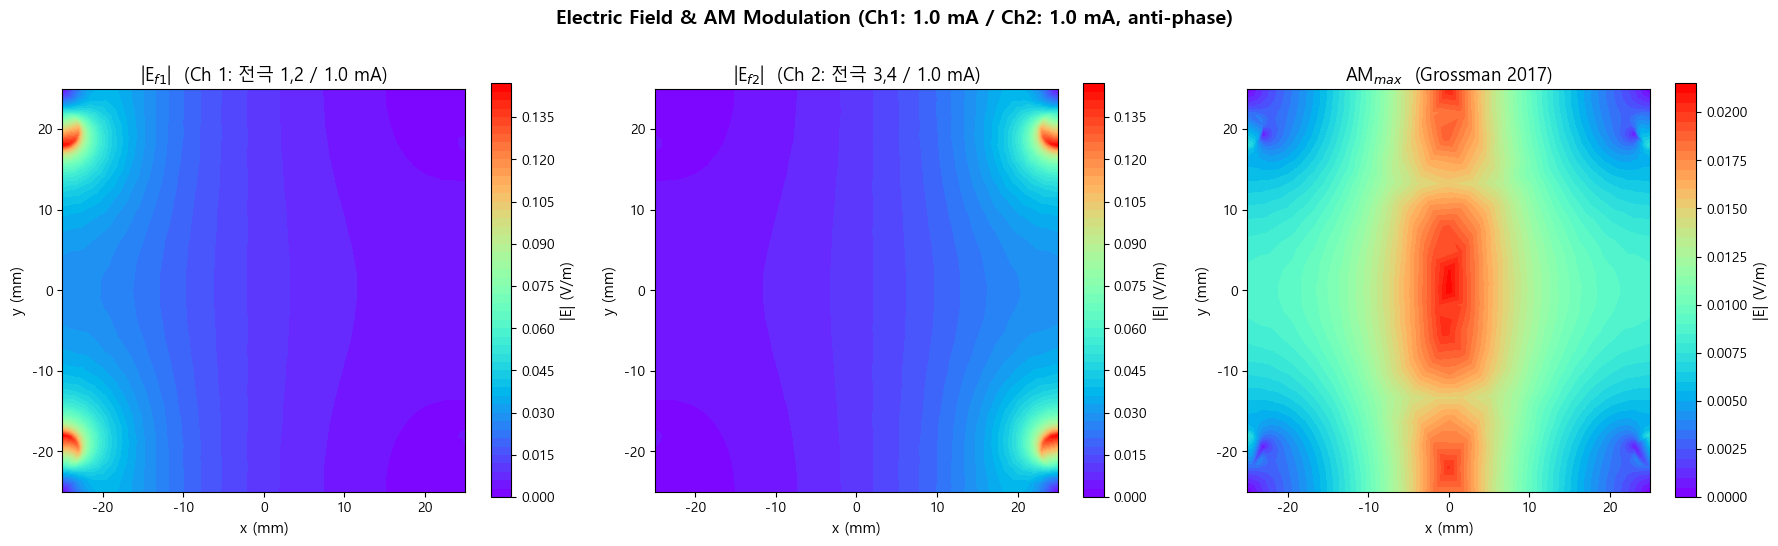

In [6]:
triang = mtri.Triangulation(x, y)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

panels = [
    (axes[0], f"|E$_{{f1}}$|  (Ch 1: 전극 1,2 / {CURRENT_F1_MA} mA)", E_mag_f1),
    (axes[1], f"|E$_{{f2}}$|  (Ch 2: 전극 3,4 / {CURRENT_F2_MA} mA)", E_mag_f2),
    (axes[2], "AM$_{max}$  (Grossman 2017)",                            AM_max),
]

for ax, title, mag in panels:
    tcf = ax.tricontourf(triang, mag, levels=50, cmap="rainbow")
    cb  = fig.colorbar(tcf, ax=ax, shrink=0.85)
    cb.set_label("|E| (V/m)", fontsize=11)
    cb.ax.tick_params(labelsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("x (mm)", fontsize=11)
    ax.set_ylabel("y (mm)", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.set_aspect("equal")

fig.suptitle(
    f"Electric Field & AM Modulation "
    f"(Ch1: {CURRENT_F1_MA} mA / Ch2: {CURRENT_F2_MA} mA, anti-phase)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
save_path = Path("efield_am_map.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path.resolve()}")
plt.show()

### 5. COMSOL 시뮬레이션 결과와 검증 (Point-level + Full-field)

COMSOL `AM_vector` surface export(`..._point_AM_vector.csv`, steady-state 전체 노드)와 Python lead field 기반 AM$_{max}$(Grossman 2017)를 **두 가지 방식**으로 교차 검증한다.

- **방법 A (Point-level)**: AM_vector 파일의 좌표마다 `cKDTree`로 가장 가까운 Python leadfield 노드를 매칭 → 보간 없이 실제 노드 값끼리 직접 비교
- **방법 B (Full-field)**: 두 데이터셋을 공통 정규 격자에 `griddata` 보간 후 비교 → 공간 분포/패턴 비교

두 방법의 정확도(RMSE, MAE, MAPE, Accuracy=100-MAPE, R²)를 나란히 비교해 서로 일관되는지 교차 검증하고, parity plot과 오차 분포 히스토그램으로 세부적으로 점검한다.

> `AM_vector_variable_system.md` 확인 결과 COMSOL `AM_vector`는 sol1/sol2 각 1mA Terminal 기준이라 Python `CURRENT_F1_MA=CURRENT_F2_MA=1.0`과 스케일이 일치 — 별도 보정 불필요.

COMSOL AM_vector 좌표 수: 6004  범위: [0.0000, 0.0213] V/m
Loading: 20260626_TI_field_Base_X50_Y50_point_leadField_f1_ver2.csv
  도메인 — x: [-25.00, 25.00] mm  y: [-25.00, 25.00] mm
  → 전극 2개 / 유효 포인트 713개 / E_tensor: (2, 713, 2)
Loading: 20260626_TI_field_Base_X50_Y50_point_leadField_f2_ver2.csv
  도메인 — x: [-25.00, 25.00] mm  y: [-25.00, 25.00] mm
  → 전극 2개 / 유효 포인트 713개 / E_tensor: (2, 713, 2)

[방법 A: Point-level, nearest-node]  n=6004  nn_dist max=2.189 mm  mean=0.598 mm
count    6.004000e+03
mean     5.086480e+00
std      8.531342e+00
min      2.265554e-09
25%      1.326703e+00
50%      3.639352e+00
75%      6.135489e+00
max      1.867042e+02
Name: diff (%), dtype: float64

오차 상위 10개 좌표:


,x (mm),y (mm),COMSOL_AM (V/m),Python_AM (V/m),diff (V/m),diff (%),nn_dist (mm)
67,23.120942,19.314744,0.000165,0.000474,0.000309,186.704236,0.164164
331,-23.120942,-19.314744,0.000198,0.000475,0.000277,140.153733,0.164164
257,23.120942,-19.314744,0.000204,0.000450,0.000246,120.772979,0.164164
332,-23.037303,-19.226366,0.000528,0.001079,0.000552,104.520556,0.239133
70,23.184598,19.161056,0.000752,0.001520,0.000767,102.036489,0.169693
258,23.184598,-19.161056,0.000771,0.001537,0.000767,99.492858,0.169693
5936,-24.507352,-25.000000,0.000389,0.000006,-0.000383,98.438047,0.492648
5933,-24.669004,-24.688045,0.000363,0.000006,-0.000357,98.325319,0.454835
5967,-25.000000,-24.561169,0.000354,0.000006,-0.000348,98.284303,0.438831
600,24.509551,25.000000,0.000387,0.000007,-0.000380,98.160311,0.490449



[방법 B: Full-field, grid interpolation]  grid=200x200
  RMSE=0.0002 V/m  MAE=0.0001 V/m  MAPE=0.59%  Accuracy=99.41%  R=0.9994  R^2=0.9989

─── 두 방법 비교 (교차 검증) ───
metric         Point(A)      Grid(B)       diff
RMSE             0.0004       0.0002     0.0002
MAE              0.0003       0.0001     0.0002
MAPE%            5.0865       0.5941     4.4924
Accuracy%       94.9135      99.4059    -4.4924
R^2              0.9933       0.9989    -0.0056
→ 두 방법이 서로 일관된 정확도를 보고함: 결과 신뢰 가능

Saved: D:\00_Project\nTIS\docs\05_Code\Simulation\efield_validation.png


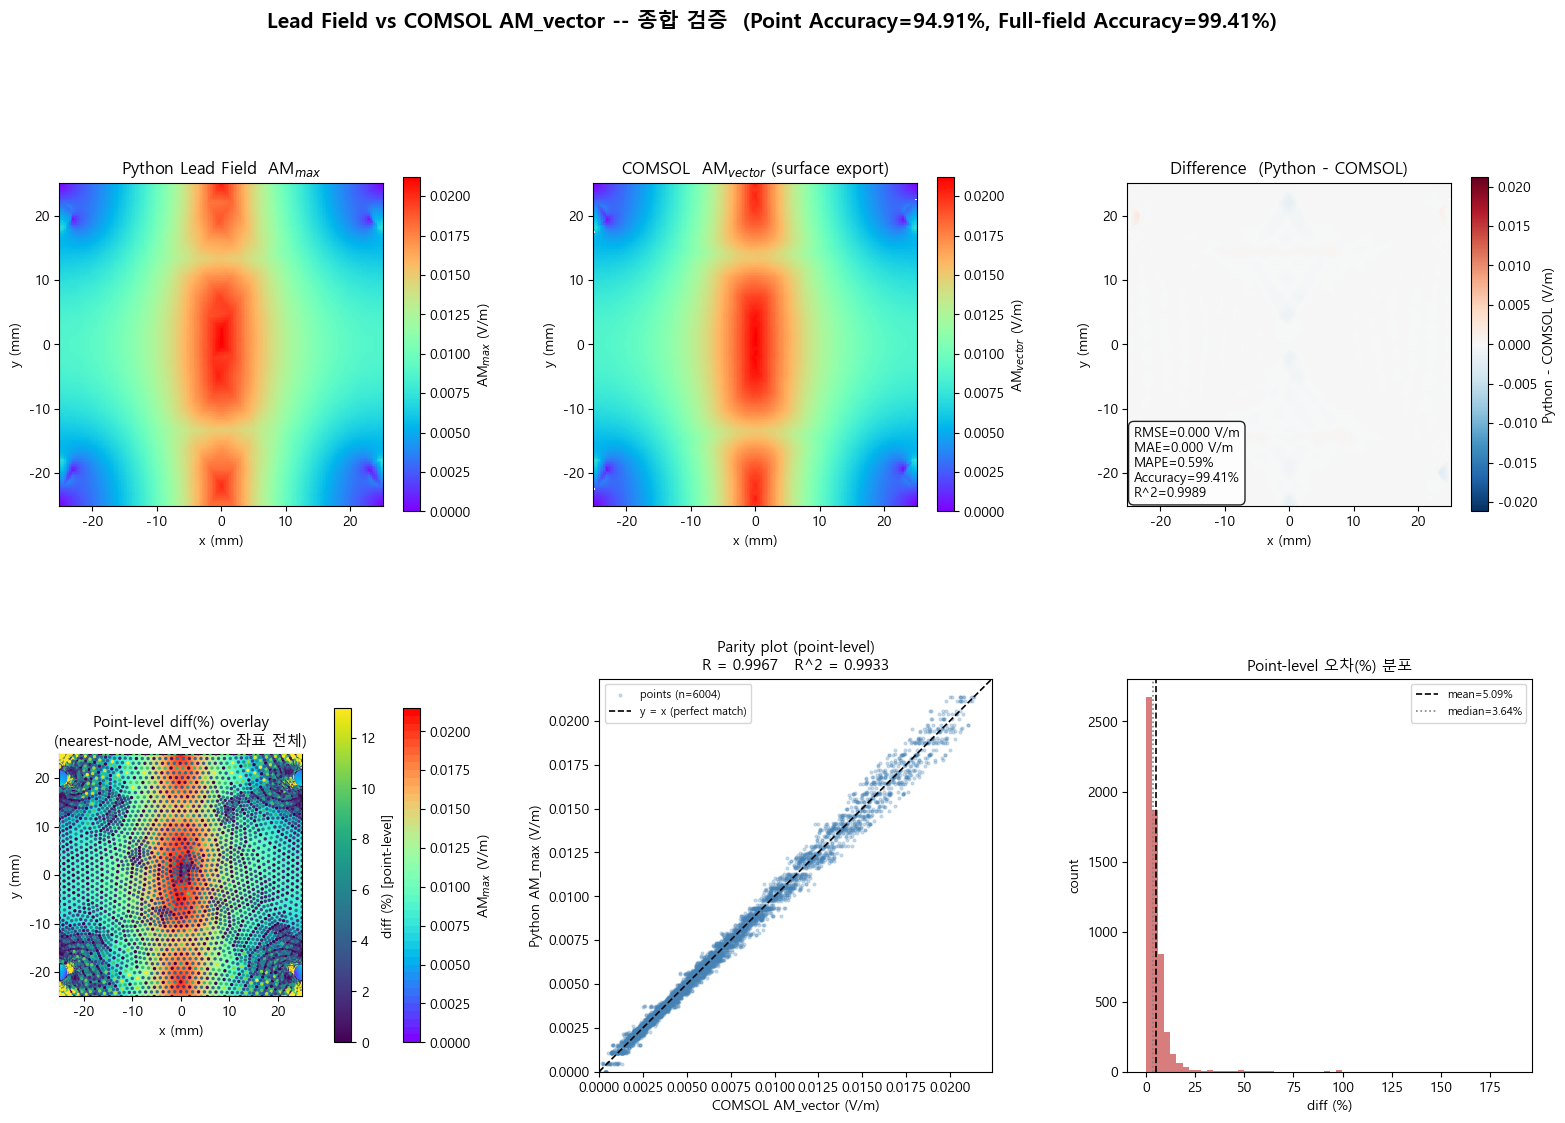

In [7]:
df_comsol_am = pd.read_csv(AM_VECTOR_FILE, comment="%", header=None,
                            names=["x", "y", "AM_vector"])
comsol_xy = df_comsol_am[["x", "y"]].values
comsol_am = df_comsol_am["AM_vector"].values
print(f"COMSOL AM_vector 좌표 수: {len(comsol_am)}  범위: [{comsol_am.min():.4f}, {comsol_am.max():.4f}] V/m")

VAL_F1, VAL_F2 = LEADFIELD_F1, LEADFIELD_F2
val_coords, val_Ef1_tensor = load_leadfield_2d(VAL_F1)
_,          val_Ef2_tensor = load_leadfield_2d(VAL_F2)
val_Ef1 = val_Ef1_tensor[0] - val_Ef1_tensor[1]
val_Ef2 = val_Ef2_tensor[0] - val_Ef2_tensor[1]
val_AM  = compute_AM_Grossman(val_Ef1, val_Ef2)


# ═══════════════════════════════════════════════════════════════════════════
# 방법 A — Point-level: AM_vector 좌표마다 nearest Python leadfield 노드 매칭
#          (mesh 대 mesh 직접 비교, 보간 없음 → 실제 값 오차)
# ═══════════════════════════════════════════════════════════════════════════
tree = cKDTree(val_coords)
nn_dist, nn_idx = tree.query(comsol_xy)

python_am_matched = val_AM[nn_idx]
diff_abs_pt = python_am_matched - comsol_am
diff_pct_pt = np.divide(
    np.abs(diff_abs_pt), np.abs(comsol_am),
    out=np.full_like(comsol_am, np.nan), where=np.abs(comsol_am) > 1e-9,
) * 100

df_val = pd.DataFrame({
    "x (mm)": comsol_xy[:, 0], "y (mm)": comsol_xy[:, 1],
    "COMSOL_AM (V/m)": comsol_am, "Python_AM (V/m)": python_am_matched,
    "diff (V/m)": diff_abs_pt, "diff (%)": diff_pct_pt, "nn_dist (mm)": nn_dist,
})

rmse_pt = np.sqrt(np.mean(diff_abs_pt ** 2))
mae_pt  = np.mean(np.abs(diff_abs_pt))
mape_pt = np.nanmean(diff_pct_pt)
acc_pt  = 100 - mape_pt
corr_pt = np.corrcoef(python_am_matched, comsol_am)[0, 1]
r2_pt   = corr_pt ** 2

print(f"\n[방법 A: Point-level, nearest-node]  n={len(df_val)}  "
      f"nn_dist max={nn_dist.max():.3f} mm  mean={nn_dist.mean():.3f} mm")
print(df_val["diff (%)"].describe())
print("\n오차 상위 10개 좌표:")
display(df_val.sort_values("diff (%)", ascending=False).head(10).round(6))


# ═══════════════════════════════════════════════════════════════════════════
# 방법 B — Full-field: 공통 정규 격자에 보간 후 비교 (공간 분포/패턴 비교용)
# ═══════════════════════════════════════════════════════════════════════════
GRID_RES = 200
xg_min = max(val_coords[:, 0].min(), comsol_xy[:, 0].min())
xg_max = min(val_coords[:, 0].max(), comsol_xy[:, 0].max())
yg_min = max(val_coords[:, 1].min(), comsol_xy[:, 1].min())
yg_max = min(val_coords[:, 1].max(), comsol_xy[:, 1].max())

xi = np.linspace(xg_min, xg_max, GRID_RES)
yi = np.linspace(yg_min, yg_max, GRID_RES)
Xi, Yi = np.meshgrid(xi, yi)

python_grid = griddata(val_coords, val_AM, (Xi, Yi), method="linear")
comsol_grid = griddata(comsol_xy, comsol_am, (Xi, Yi), method="linear")
diff_grid   = python_grid - comsol_grid

valid_mask = ~(np.isnan(diff_grid) | np.isnan(python_grid) | np.isnan(comsol_grid))
p_valid, c_valid, d_valid = python_grid[valid_mask], comsol_grid[valid_mask], diff_grid[valid_mask]

rmse_gd = np.sqrt(np.mean(d_valid ** 2))
mae_gd  = np.mean(np.abs(d_valid))
nz      = np.abs(c_valid) > 1e-9
mape_gd = np.mean(np.abs(d_valid[nz]) / np.abs(c_valid[nz])) * 100
acc_gd  = 100 - mape_gd
corr_gd = np.corrcoef(p_valid, c_valid)[0, 1]
r2_gd   = corr_gd ** 2

print(f"\n[방법 B: Full-field, grid interpolation]  grid={GRID_RES}x{GRID_RES}")
print(f"  RMSE={rmse_gd:.4f} V/m  MAE={mae_gd:.4f} V/m  MAPE={mape_gd:.2f}%  "
      f"Accuracy={acc_gd:.2f}%  R={corr_gd:.4f}  R^2={r2_gd:.4f}")

# ── 두 방법 교차검증 (critical check) ─────────────────────────────────────────
print("\n─── 두 방법 비교 (교차 검증) ───")
print(f"{'metric':10s} {'Point(A)':>12s} {'Grid(B)':>12s} {'diff':>10s}")
for name, a, b in [("RMSE", rmse_pt, rmse_gd), ("MAE", mae_pt, mae_gd),
                    ("MAPE%", mape_pt, mape_gd), ("Accuracy%", acc_pt, acc_gd),
                    ("R^2", r2_pt, r2_gd)]:
    print(f"{name:10s} {a:12.4f} {b:12.4f} {a - b:10.4f}")
if abs(acc_pt - acc_gd) > 5:
    print("[주의] 두 방법의 정확도 차이가 5%p 이상 — griddata 보간 스무딩 또는 "
          "mesh 해상도 차이로 인한 인공적 오차 가능성 점검 필요")
else:
    print("→ 두 방법이 서로 일관된 정확도를 보고함: 결과 신뢰 가능")


# ═══════════════════════════════════════════════════════════════════════════
# 종합 시각화 — 2행 3열
#  Row1: Full-field  [Python | COMSOL | Diff]
#  Row2: 진단        [Point diff% overlay | Parity plot | Error histogram]
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(19, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.32)

vmax_field = np.nanmax([np.nanmax(python_grid), np.nanmax(comsol_grid)])

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.pcolormesh(Xi, Yi, python_grid, cmap="rainbow", vmin=0, vmax=vmax_field, shading="auto")
fig.colorbar(im1, ax=ax1, shrink=0.85, label="AM$_{max}$ (V/m)")
ax1.set_title("Python Lead Field  AM$_{max}$", fontsize=12)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.pcolormesh(Xi, Yi, comsol_grid, cmap="rainbow", vmin=0, vmax=vmax_field, shading="auto")
fig.colorbar(im2, ax=ax2, shrink=0.85, label="AM$_{vector}$ (V/m)")
ax2.set_title("COMSOL  AM$_{vector}$ (surface export)", fontsize=12)

# diff colorbar 범위를 field 범위(vmax_field)에 맞춤 → 두 필드가 유사한 스케일임이 시각적으로 드러남
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.pcolormesh(Xi, Yi, diff_grid, cmap="RdBu_r", vmin=-vmax_field, vmax=vmax_field, shading="auto")
fig.colorbar(im3, ax=ax3, shrink=0.85, label="Python - COMSOL (V/m)")
ax3.set_title("Difference  (Python - COMSOL)", fontsize=12)
ax3.text(0.02, 0.02,
         f"RMSE={rmse_gd:.3f} V/m\nMAE={mae_gd:.3f} V/m\nMAPE={mape_gd:.2f}%\n"
         f"Accuracy={acc_gd:.2f}%\nR^2={r2_gd:.4f}",
         transform=ax3.transAxes, fontsize=9.5, va="bottom", ha="left",
         bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.85))

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("x (mm)", fontsize=10); ax.set_ylabel("y (mm)", fontsize=10)
    ax.set_aspect("equal")

# (2,1) Point-level diff% overlay
ax4 = fig.add_subplot(gs[1, 0])
triang_val = mtri.Triangulation(x, y)
tcf = ax4.tricontourf(triang_val, AM_max, levels=50, cmap="rainbow")
fig.colorbar(tcf, ax=ax4, shrink=0.85, label="AM$_{max}$ (V/m)")
diff_vmax_pt = np.nanpercentile(df_val["diff (%)"], 95)
sc = ax4.scatter(df_val["x (mm)"], df_val["y (mm)"], c=df_val["diff (%)"],
                  cmap="viridis", s=6, vmin=0, vmax=diff_vmax_pt, edgecolors="none", zorder=10)
fig.colorbar(sc, ax=ax4, shrink=0.85, pad=0.1, label="diff (%) [point-level]")
ax4.set_title("Point-level diff(%) overlay\n(nearest-node, AM_vector 좌표 전체)", fontsize=11)
ax4.set_xlabel("x (mm)", fontsize=10); ax4.set_ylabel("y (mm)", fontsize=10)
ax4.set_aspect("equal")

# (2,2) Parity plot — COMSOL vs Python (y=x)
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df_val["COMSOL_AM (V/m)"], df_val["Python_AM (V/m)"],
            s=4, alpha=0.25, color="steelblue", label=f"points (n={len(df_val)})")
lims = [0, max(df_val["COMSOL_AM (V/m)"].max(), df_val["Python_AM (V/m)"].max()) * 1.05]
ax5.plot(lims, lims, "k--", lw=1.2, label="y = x (perfect match)")
ax5.set_xlim(lims); ax5.set_ylim(lims)
ax5.set_xlabel("COMSOL AM_vector (V/m)", fontsize=10)
ax5.set_ylabel("Python AM_max (V/m)", fontsize=10)
ax5.set_title(f"Parity plot (point-level)\nR = {corr_pt:.4f}   R^2 = {r2_pt:.4f}", fontsize=11)
ax5.legend(fontsize=8, loc="upper left")
ax5.set_aspect("equal")

# (2,3) Error histogram
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_val["diff (%)"].dropna(), bins=60, color="indianred", alpha=0.8)
ax6.axvline(mape_pt, color="black", ls="--", lw=1.2, label=f"mean={mape_pt:.2f}%")
ax6.axvline(np.nanmedian(df_val["diff (%)"]), color="gray", ls=":", lw=1.2,
            label=f"median={np.nanmedian(df_val['diff (%)']):.2f}%")
ax6.set_xlabel("diff (%)", fontsize=10)
ax6.set_ylabel("count", fontsize=10)
ax6.set_title("Point-level 오차(%) 분포", fontsize=11)
ax6.legend(fontsize=8)

fig.suptitle(
    f"Lead Field vs COMSOL AM_vector -- 종합 검증  "
    f"(Point Accuracy={acc_pt:.2f}%, Full-field Accuracy={acc_gd:.2f}%)",
    fontsize=15, fontweight="bold", y=0.995,
)
plt.tight_layout()
val_save = Path("efield_validation.png")
plt.savefig(val_save, dpi=150, bbox_inches="tight")
print(f"\nSaved: {val_save.resolve()}")
plt.show()

## 6. CSV 저장

In [8]:
out_path = Path("efield_magnitude_result.csv")
df_result.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")
df_result.describe()

Saved: D:\00_Project\nTIS\docs\05_Code\Simulation\efield_magnitude_result.csv


,x (mm),y (mm),Ex_f1 (V/m),Ey_f1 (V/m),|E_f1| (V/m),Ex_f2 (V/m),Ey_f2 (V/m),|E_f2| (V/m),AM_max (V/m)
count,7.130000e+02,713.000000,7.130000e+02,713.000000,713.000000,7.130000e+02,713.000000,713.000000,713.000000
mean,-1.317313e-01,-0.319092,-6.010901e-04,-0.010893,0.026624,2.166785e-04,-0.010754,0.025897,0.006568
std,1.943960e+01,17.854240,3.018428e-02,0.027135,0.032508,2.918367e-02,0.026784,0.031833,0.004624
min,-2.500000e+01,-25.000000,-1.175740e-01,-0.144894,0.000004,-1.174088e-01,-0.144923,0.000003,0.000006
25%,-2.151657e+01,-18.509780,-3.744485e-03,-0.015712,0.002650,-3.043614e-03,-0.015678,0.002469,0.002981
50%,-2.803269e-11,-1.468555,-8.258809e-07,-0.003169,0.010489,4.638976e-07,-0.003211,0.010275,0.005260
75%,2.118140e+01,18.073555,2.932953e-03,-0.000818,0.041608,3.279188e-03,-0.000788,0.039783,0.008876
max,2.500000e+01,25.000000,1.173518e-01,0.056344,0.144902,1.173139e-01,0.056349,0.144931,0.021340
